In [24]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/gdrive")

%cd "/content/gdrive/MyDrive/datasets"

# columns has the name of each column.
df_raw = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv', delimiter=',', encoding='latin1')
df_raw.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/MyDrive/datasets


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [25]:
# Información del dataset sin procesar
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

#EDA

In [26]:
# Copia al dataframe que se va a procesar
df = df_raw.copy()
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [27]:
# Quitar columnas que no son útiles para el modelo
df.drop(columns=["transaction_id"], inplace=True)
df.drop(columns=["user_id"], inplace=True)

In [28]:
# Rellenar los valores NaN con None (el dataset original tenía como categría válida los None)
df["addiction_level"].fillna("None", inplace=True)

/tmp/ipykernel_4564/27730445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["addiction_level"].fillna("None", inplace=True)


In [29]:
# Cambiar a valores numéricos los valores de YES y NO
df['academic_work_impact'] = df['academic_work_impact'].map({'Yes': 1, 'No': 0})
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,1,None,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,1,None,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,0,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,1,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,0,Severe,1


In [30]:
# Generar variables dummies para las features categóricas
df = pd.get_dummies(df, columns=['gender', 'stress_level', 'addiction_level'], drop_first=False)
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,academic_work_impact,...,gender_Female,gender_Male,gender_Other,stress_level_High,stress_level_Low,stress_level_Medium,addiction_level_Mild,addiction_level_Moderate,addiction_level_None,addiction_level_Severe
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,...,False,True,False,False,False,True,False,False,True,False
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,...,False,False,True,False,False,True,False,False,True,False
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,...,False,False,True,True,False,False,True,False,False,False
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,1,...,False,False,True,True,False,False,False,True,False,False
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,...,False,True,False,False,True,False,False,False,False,True


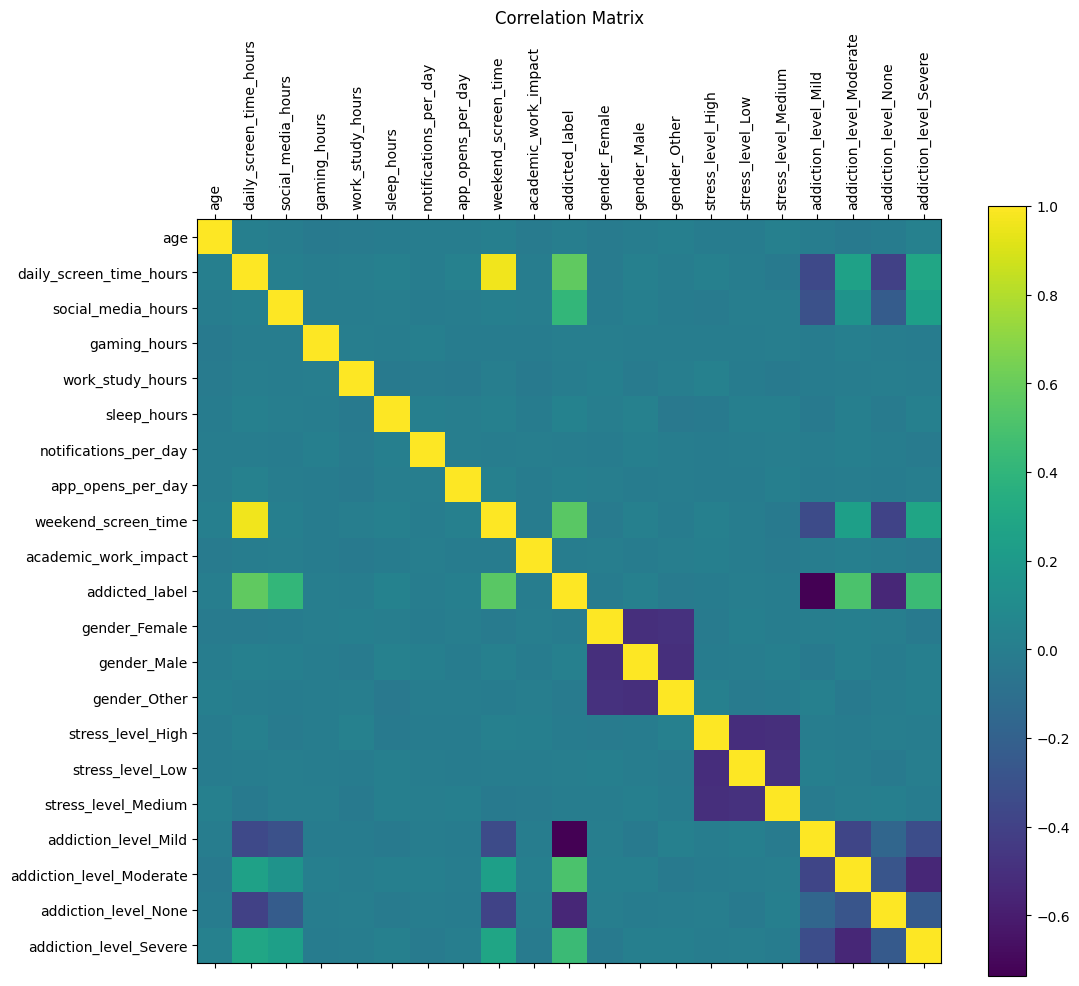

In [31]:
# Matriz de correlación
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10)) # Create figure and axes
cax = ax.matshow(corr_matrix.values) # Plot on the axes
fig.colorbar(cax) # Add colorbar to the figure
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
plt.title('Correlation Matrix') # Title can be set on figure or ax
plt.show()

In [32]:
# Información del dataset procesado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       7500 non-null   int64  
 1   daily_screen_time_hours   7500 non-null   float64
 2   social_media_hours        7500 non-null   float64
 3   gaming_hours              7500 non-null   float64
 4   work_study_hours          7500 non-null   float64
 5   sleep_hours               7500 non-null   float64
 6   notifications_per_day     7500 non-null   int64  
 7   app_opens_per_day         7500 non-null   int64  
 8   weekend_screen_time       7500 non-null   float64
 9   academic_work_impact      7500 non-null   int64  
 10  addicted_label            7500 non-null   int64  
 11  gender_Female             7500 non-null   bool   
 12  gender_Male               7500 non-null   bool   
 13  gender_Other              7500 non-null   bool   
 14  stress_l

#SEPARACIÓN DE TRAIN, VAL Y TEST


In [33]:
# Separación de dataset con el formato 80% train, 10% validation, 10% test
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42)

df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Training set shape: {df_train.shape}")
print(f"Validation set shape: {df_val.shape}")
print(f"Test set shape: {df_test.shape}")

Training set shape: (6000, 21)
Validation set shape: (750, 21)
Test set shape: (750, 21)
